In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models & Metrics
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load your exact student dataset
df = pd.read_csv('student.csv')

print(f"Dataset Shape: {df.shape}")
print("\n--- First 5 Rows ---")
display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'student.csv'

In [2]:
import os
import pandas as pd

# Point Python to your Desktop folder (adjust 'YourUsername' or path if needed)
# For Windows:
os.chdir(r"C:\Users\IOT-18\Desktop\stds")


# Now load the file directly
df = pd.read_csv('student.csv')
print("Successfully loaded dataset! Shape:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\IOT-18\\Desktop\\stds'

In [3]:
import pandas as pd
from google.colab import files
import io

# 1. This will open a "Choose Files" button in Colab
print("Please select and upload 'student.csv' from your desktop folder:")
uploaded = files.upload()

# 2. Read the uploaded file directly into pandas
df = pd.read_csv(io.BytesIO(uploaded['student.csv']))

print("\nSuccessfully loaded dataset! Shape:", df.shape)
df.head()

Please select and upload 'student.csv' from your desktop folder:


Saving student.csv to student.csv

Successfully loaded dataset! Shape: (30, 10)


,NAME,AGE,ATTENDANCE,EXAM SCORE,VIDEO GAMES,TUTION,HEALTH,STRESS,DAILY WORK,SELF STUDY
0,raju,18.0,100.0,89.0,0.5,yes,GOOD,LOW,SATISFACTORY,4.0
1,bheem,19.0,90.0,95.0,0.5,yes,GOOD,LOW,SATISFACTORY,5.0
2,vignesh,22.0,90.0,96.0,0.5,yes,GOOD,LOW,SATISFACTORY,5.0
3,arun,18.0,80.0,73.0,2.0,no,BAD,MODERATE,BELOW AVERAGE,2.0
4,ankush,20.0,100.0,97.0,0.5,yes,GOOD,LOW,SATISFACTORY,5.0


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   NAME         30 non-null     object 
 1   AGE          29 non-null     float64
 2   ATTENDANCE   29 non-null     float64
 3   EXAM SCORE   28 non-null     float64
 4   VIDEO GAMES  29 non-null     float64
 5   TUTION       29 non-null     object 
 6   HEALTH       30 non-null     object 
 7   STRESS       30 non-null     object 
 8   DAILY WORK   30 non-null     object 
 9   SELF STUDY   30 non-null     float64
dtypes: float64(5), object(5)
memory usage: 2.5+ KB

--- Missing Values Count ---
NAME           0
AGE            1
ATTENDANCE     1
EXAM SCORE     2
VIDEO GAMES    1
TUTION         1
HEALTH         0
STRESS         0
DAILY WORK     0
SELF STUDY     0
dtype: int64


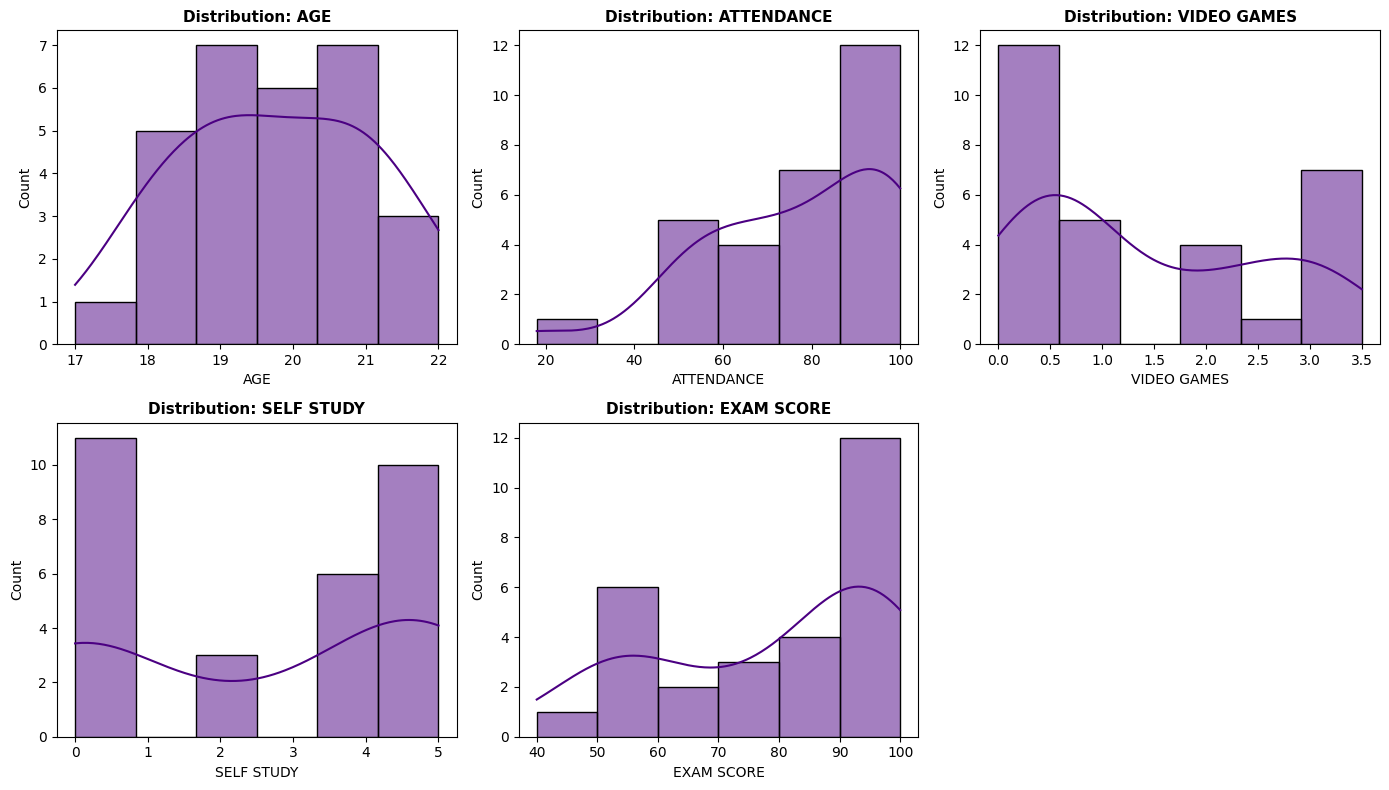

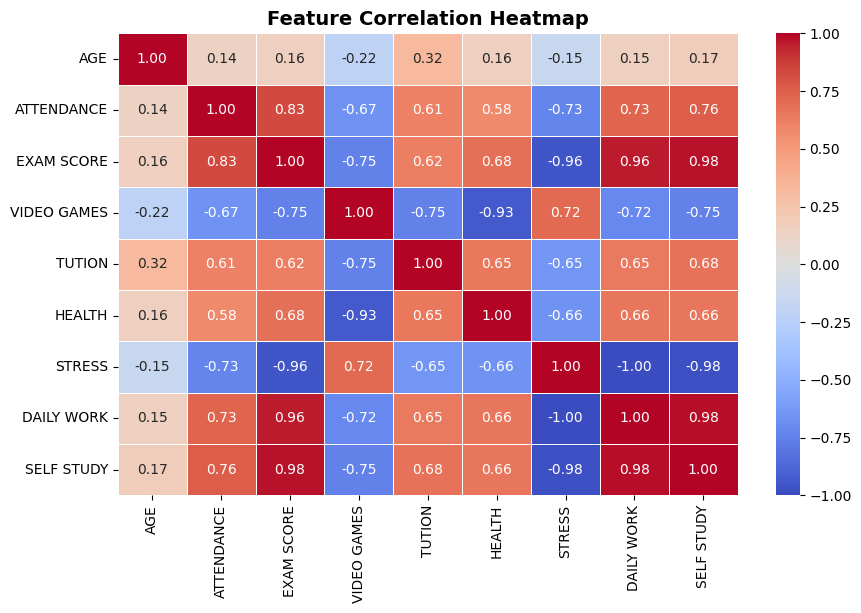

In [4]:
# --- 1. Dataset Overview ---
print("--- Dataset Info ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# --- 2. Numerical Features Distribution Plots ---
plt.figure(figsize=(14, 8))
numeric_cols = ['AGE', 'ATTENDANCE', 'VIDEO GAMES', 'SELF STUDY', 'EXAM SCORE']

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col].dropna(), kde=True, color='indigo')
    plt.title(f'Distribution: {col}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# --- 3. Feature Correlation Heatmap ---
plt.figure(figsize=(10, 6))
corr_df = df.copy().drop(columns=['NAME'])

# Numerical encoding for correlation visualization
corr_df['TUTION'] = corr_df['TUTION'].map({'yes': 1, 'no': 0})
corr_df['HEALTH'] = corr_df['HEALTH'].map({'GOOD': 1, 'BAD': 0})
corr_df['STRESS'] = corr_df['STRESS'].map({'LOW': 1, 'MODERATE': 2, 'HIGH': 3})
corr_df['DAILY WORK'] = corr_df['DAILY WORK'].map({'SATISFACTORY': 1, 'BELOW AVERAGE': 0, 'POOR': -1})

sns.heatmap(corr_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

In [5]:
# --- 1. Target and Feature Split ---
X = df.drop(columns=['NAME', 'EXAM SCORE'])
y = df['EXAM SCORE']

# Exclude rows missing target values
valid_y_idx = y.notnull()
X = X[valid_y_idx]
y = y[valid_y_idx]

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. Preprocessing Pipelines ---
num_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# --- 3. Model 1: Baseline Model (Linear Regression) ---
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# --- 4. Model 2: Advanced Model (Random Forest Regressor) ---
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Models built and trained successfully!")

Models built and trained successfully!


In [7]:
# Function to calculate evaluation metrics
def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

rmse_lr, r2_lr = calculate_metrics(y_test, y_pred_lr)
rmse_rf, r2_rf = calculate_metrics(y_test, y_pred_rf)

# Display Comparison Table
results_df = pd.DataFrame({
    'Model Name': ['Linear Regression (Baseline)', 'Random Forest (Advanced)'],
    'RMSE': [round(rmse_lr, 3), round(rmse_rf, 3)],
    'R² Score': [round(r2_lr, 4), round(r2_rf, 4)]
})

print("\n================ MODEL PERFORMANCE COMPARISON ================")
print(results_df.to_string(index=False))
print("==========================================================")


================ MODEL PERFORMANCE COMPARISON ================
                  Model Name  RMSE  R² Score
Linear Regression (Baseline) 1.538    0.9934
    Random Forest (Advanced) 3.125    0.9728
